# AKI Prediction — MIMIC-IV Demo
**Pipeline:** SQL extraction → Feature engineering → Model training → Calibration → SHAP

This notebook is a self-contained RAISE-AKI prototype running on real clinical data  
from the publicly available MIMIC-IV demo (100 de-identified patients, Beth Israel Deaconess Medical Center).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
os.environ['MPLCONFIGDIR'] = '/tmp/mpl'
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from data     import load_mimic, build_cohort
from features import build_preprocessor, get_X_y
from models   import get_models, build_pipeline, evaluate, calibrate, plot_calibration, plot_roc
from explain  import get_feature_names

RESULTS = '../results'
DATA    = '../data/mimic_iv_demo'
os.makedirs(RESULTS, exist_ok=True)
print('Setup complete.')

Setup complete.


## Step 1 — Extract Cohort (SQL → DataFrame)

In [2]:
conn = load_mimic(DATA)
df   = build_cohort(conn)

print(f'Cohort : {df.shape[0]} admissions × {df.shape[1]} columns')
print(f'AKI    : {df.aki_label.sum()} / {len(df)}  ({df.aki_label.mean():.1%})')
print(f'Stages : {df.aki_stage.value_counts().sort_index().to_dict()}')
df.to_csv(f'{RESULTS}/cohort.csv', index=False)
df.head(3)

  Loaded patients
  Loaded admissions


  Loaded labevents
  Loaded prescriptions
  Loaded diagnoses_icd
  Loaded icustays


  Loaded chartevents
  Loaded d_items
Cohort : 250 admissions × 23 columns
AKI    : 50 / 250  (20.0%)
Stages : {0: 200, 1: 34, 2: 12, 3: 4}


,hadm_id,subject_id,age,gender,admission_type,insurance,race,los_days,died_in_hospital,baseline_creatinine,...,delta_creatinine,creatinine_ratio,mean_map,min_map,pct_hypotensive,mean_hr,n_icu_stays,icu_los_days,aki_label,aki_stage
0,20044587,10023771,70,M,ELECTIVE,Medicare,WHITE,5.3,0,1.0,...,0.0,1.00,76.4,56.0,8.4,74.7,1,2.3,0,0
1,20093566,10039708,46,F,OBSERVATION ADMIT,Other,BLACK/AFRICAN AMERICAN,4.1,0,9.7,...,0.6,1.06,-1.0,-1.0,-1.0,-1.0,0,0.0,1,1
2,20192635,10037928,78,F,EW EMER.,Medicare,HISPANIC/LATINO - CUBAN,3.2,0,1.3,...,0.0,1.00,-1.0,-1.0,-1.0,-1.0,0,0.0,0,0


In [3]:
# AKI vs No-AKI descriptive comparison
cols = ['age','los_days','baseline_creatinine','egfr','peak_creatinine','delta_creatinine','mean_map']
df.groupby('aki_label')[cols].mean().round(2)

,age,los_days,baseline_creatinine,egfr,peak_creatinine,delta_creatinine,mean_map
aki_label,,,,,,,
0,61.71,6.08,1.34,84.35,1.38,0.04,36.52
1,60.68,12.51,2.15,64.07,3.42,1.27,64.20


## Step 2 — Feature Engineering + Split

In [4]:
X, y = get_X_y(df)

# Ordered split (80/20) — respects admission order, avoids temporal leakage
n = len(X)
split = int(n * 0.8)
X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()

print(f'Features : {X.shape[1]}')
print(f'Train    : {len(X_train)} samples  (AKI={y_train.mean():.1%})')
print(f'Test     : {len(X_test)} samples  (AKI={y_test.mean():.1%})')

Features : 16
Train    : 200 samples  (AKI=16.5%)
Test     : 50 samples  (AKI=34.0%)


## Step 3 — Train + Calibrate All Models

In [5]:
preprocessor = build_preprocessor()
results      = []
trained      = {}   # name → (raw_pipeline, calibrated_pipeline)

for name, estimator in get_models().items():
    print(f'\n── {name} ──')
    pipe = build_pipeline(preprocessor, estimator)
    pipe.fit(X_train, y_train)

    # Isotonic calibration (best for ≥ 1k samples — Niculescu-Mizil & Caruana, ICML 2005)
    cal  = calibrate(pipe, X_train, y_train)

    result = evaluate(cal, X_test, y_test, name=name)
    results.append(result)
    trained[name] = (pipe, cal)


── Logistic Regression ──

  Logistic Regression
  AUROC : 0.846
  Brier : 0.163  (0=perfect, 0.25=baseline)
              precision    recall  f1-score   support

      No AKI       0.76      0.94      0.84        33
         AKI       0.78      0.41      0.54        17

    accuracy                           0.76        50
   macro avg       0.77      0.68      0.69        50
weighted avg       0.76      0.76      0.74        50


── Random Forest ──



  Random Forest
  AUROC : 0.865
  Brier : 0.166  (0=perfect, 0.25=baseline)
              precision    recall  f1-score   support

      No AKI       0.72      1.00      0.84        33
         AKI       1.00      0.24      0.38        17

    accuracy                           0.74        50
   macro avg       0.86      0.62      0.61        50
weighted avg       0.81      0.74      0.68        50


── Gradient Boosting ──



  Gradient Boosting
  AUROC : 0.861
  Brier : 0.156  (0=perfect, 0.25=baseline)
              precision    recall  f1-score   support

      No AKI       0.80      0.97      0.88        33
         AKI       0.90      0.53      0.67        17

    accuracy                           0.82        50
   macro avg       0.85      0.75      0.77        50
weighted avg       0.83      0.82      0.81        50



In [6]:
# Summary table
summary = pd.DataFrame([
    {'Model': r['name'], 'AUROC': round(r['auroc'], 3), 'Brier': round(r['brier'], 3)}
    for r in results
]).sort_values('AUROC', ascending=False)

print(summary.to_string(index=False))
summary.to_csv(f'{RESULTS}/model_scores.csv', index=False)

              Model  AUROC  Brier
      Random Forest  0.865  0.166
  Gradient Boosting  0.861  0.156
Logistic Regression  0.846  0.163


## Step 4 — Calibration & ROC Curves

Saved: ../results/roc_curves.png
Saved: ../results/calibration_curves.png


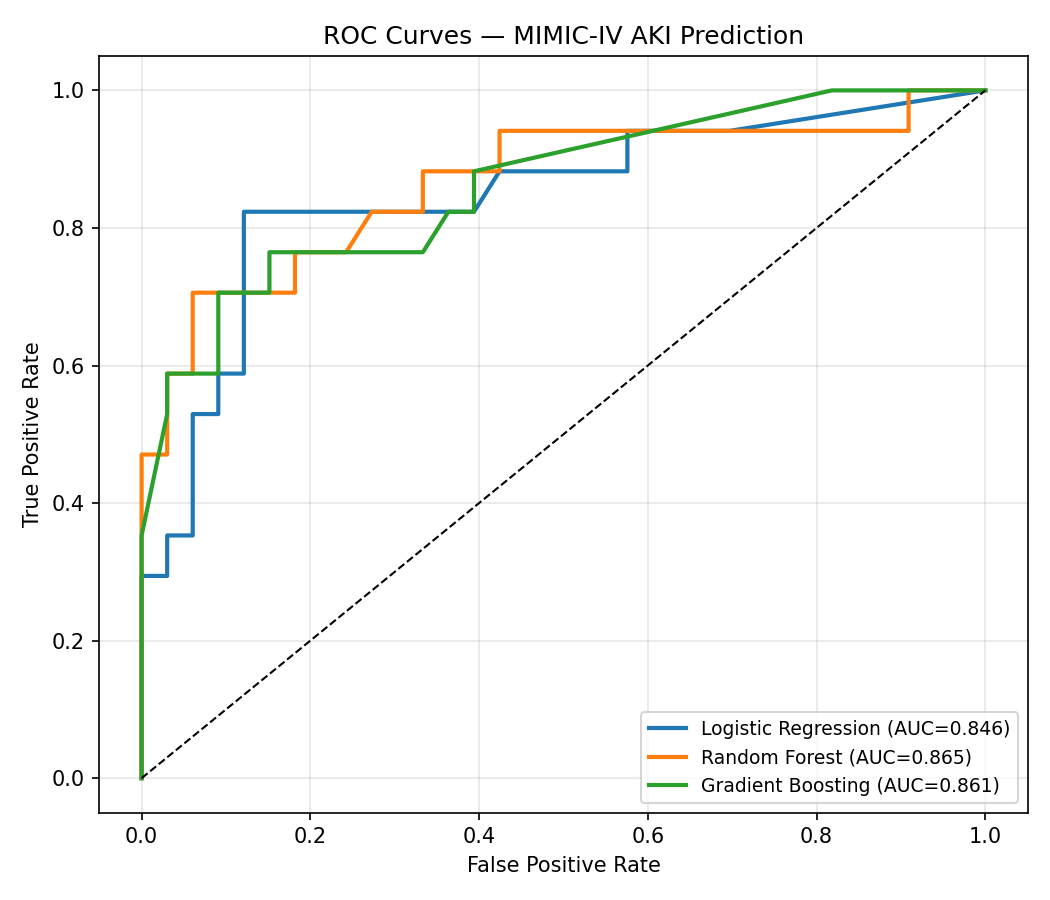

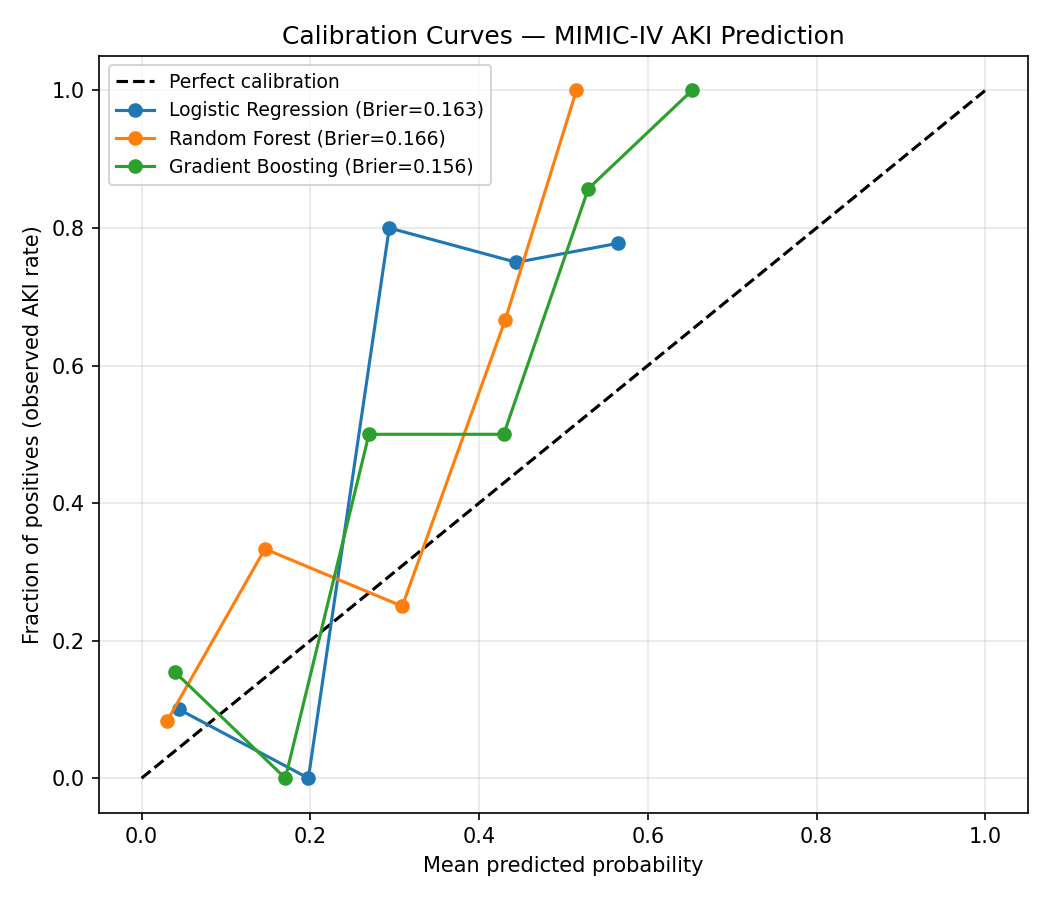

In [7]:
plot_roc(results,         y_test, save_path=f'{RESULTS}/roc_curves.png')
plot_calibration(results, y_test, save_path=f'{RESULTS}/calibration_curves.png')

from IPython.display import Image, display
display(Image(f'{RESULTS}/roc_curves.png'))
display(Image(f'{RESULTS}/calibration_curves.png'))

## Step 5 — SHAP Interpretability

In [8]:
# Use Gradient Boosting for SHAP — it returns clean 2D values (n_samples, n_features)
# RF returns 3D (n_samples, n_features, 2); LR needs a different explainer
shap_name = 'Gradient Boosting'
best_name = summary.iloc[0]['Model']   # best model for scoring
best_pipe, _ = trained[best_name]
shap_pipe, _ = trained[shap_name]
print(f'Best model (AUROC) : {best_name}')
print(f'SHAP model         : {shap_name}')

prep_fitted = shap_pipe.named_steps['prep']
clf_fitted  = shap_pipe.named_steps['clf']
feat_names  = get_feature_names(prep_fitted)

X_train_t = prep_fitted.transform(X_train)
X_test_t  = prep_fitted.transform(X_test)

explainer   = shap.TreeExplainer(clf_fitted)
shap_values = explainer.shap_values(X_test_t)
# Normalise to 2D: older shap returns list; RF returns (n, f, 2)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print(f'SHAP values shape: {shap_values.shape}  ({len(feat_names)} features)')

Best model (AUROC) : Random Forest
SHAP model         : Gradient Boosting
SHAP values shape: (50, 25)  (25 features)


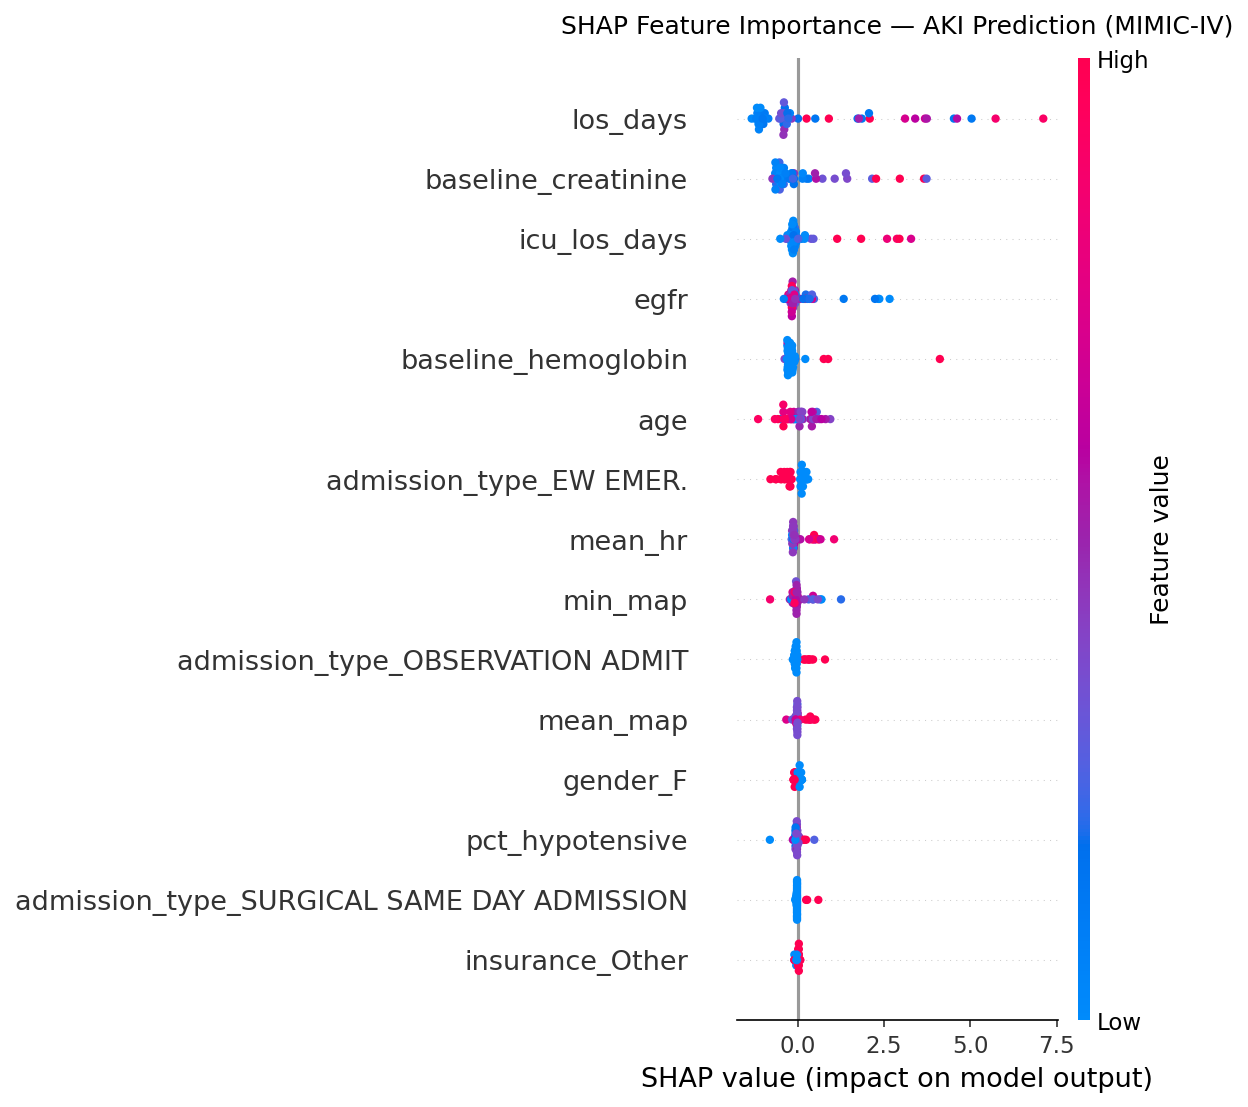

In [9]:
# Global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_t,
    feature_names=feat_names,
    show=False, max_display=15
)
plt.title('SHAP Feature Importance — AKI Prediction (MIMIC-IV)', pad=12)
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image(f'{RESULTS}/shap_summary.png'))

In [10]:
# Feature importance table
importance = pd.DataFrame({
    'feature':   feat_names,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print('Top 10 features by mean |SHAP|:')
print(importance.head(10).to_string(index=False))
importance.to_csv(f'{RESULTS}/shap_importance.csv', index=False)

Top 10 features by mean |SHAP|:
                         feature  mean_shap
                        los_days   1.508722
             baseline_creatinine   0.733465
                    icu_los_days   0.434006
                            egfr   0.394284
             baseline_hemoglobin   0.320527
                             age   0.307898
         admission_type_EW EMER.   0.245509
                         mean_hr   0.216767
                         min_map   0.170510
admission_type_OBSERVATION ADMIT   0.109125


Highest-risk patient (test index 2)
  Predicted probability : 65.2%
  Actual AKI label      : 1


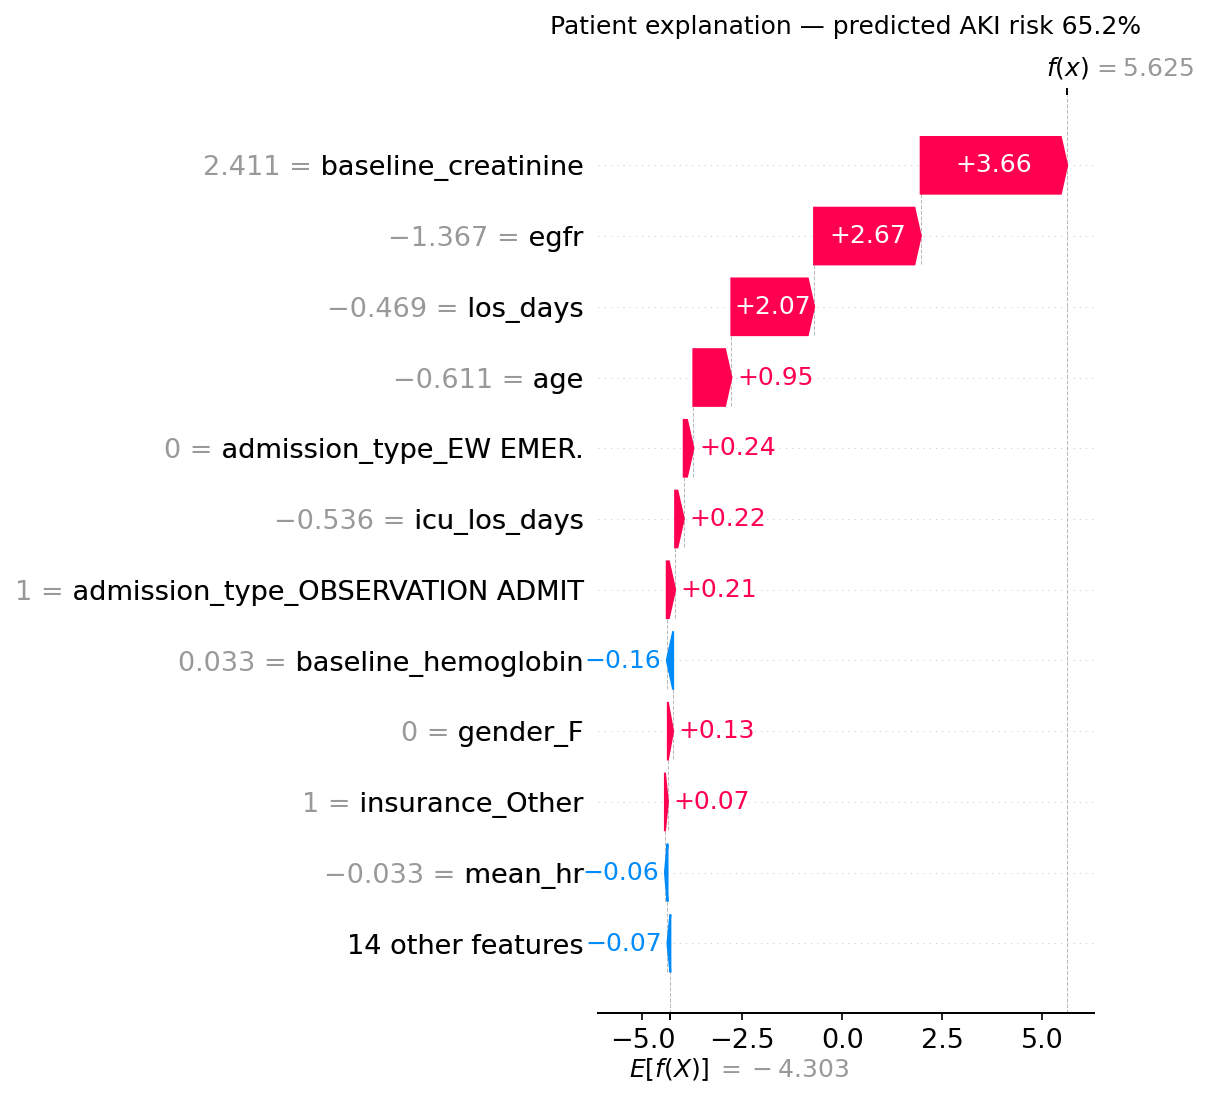

In [11]:
# Local explanation — highest-risk patient in test set
shap_result   = next(r for r in results if r['name'] == shap_name)
high_risk_idx = int(np.argmax(shap_result['y_prob']))

print(f'Highest-risk patient (test index {high_risk_idx})')
print(f'  Predicted probability : {shap_result["y_prob"][high_risk_idx]:.1%}')
print(f'  Actual AKI label      : {int(y_test.iloc[high_risk_idx])}')

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(np.array(base_val).flat[-1])  # last element = positive class

explanation = shap.Explanation(
    values       = shap_values[high_risk_idx],
    base_values  = float(base_val),
    data         = X_test_t[high_risk_idx],
    feature_names= feat_names
)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False, max_display=12)
plt.title(f'Patient explanation — predicted AKI risk {shap_result["y_prob"][high_risk_idx]:.1%}', pad=10)
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image(f'{RESULTS}/shap_waterfall.png'))

## Final Summary

In [12]:
print('=' * 55)
print('  RAISE-AKI  |  MIMIC-IV Demo Results')
print('=' * 55)
print(f'  Cohort       : {len(df)} admissions')
print(f'  AKI rate     : {df.aki_label.mean():.1%}')
print(f'  Train / Test : {len(X_train)} / {len(X_test)}')
print(f'  Features     : {X.shape[1]}')
print()
for _, row in summary.iterrows():
    print(f"  {row['Model']:<28}  AUROC={row['AUROC']}  Brier={row['Brier']}")
print()
print(f'  Best model   : {best_name}')
print(f'  Top feature  : {importance.iloc[0].feature}')
print('=' * 55)
print(f'  Results in   : results/')

import glob
for f in sorted(glob.glob(f'{RESULTS}/*')):
    size = os.path.getsize(f)
    print(f'    {os.path.basename(f):<35} {size/1024:.1f} KB')

  RAISE-AKI  |  MIMIC-IV Demo Results
  Cohort       : 250 admissions
  AKI rate     : 20.0%
  Train / Test : 200 / 50
  Features     : 16

  Random Forest                 AUROC=0.865  Brier=0.166
  Gradient Boosting             AUROC=0.861  Brier=0.156
  Logistic Regression           AUROC=0.846  Brier=0.163

  Best model   : Random Forest
  Top feature  : los_days
  Results in   : results/
    calibration_curves.png              98.4 KB
    cohort.csv                          27.8 KB
    model_scores.csv                    0.1 KB
    roc_curves.png                      67.2 KB
    shap_importance.csv                 0.9 KB
    shap_summary.png                    115.0 KB
    shap_waterfall.png                  104.7 KB
